In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/")

import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd
import json
from pathlib import Path

import numpy as np
import seaborn as sns
import os
from analysis.utils import load_sweep_metadata, load_data, compute_success, chunk_data
from analysis.utils_decoding import evaluate_lags_leave_k_out
from analysis.utils import chunk_data

## Load data

## Plotting

In [3]:
import pickle

path_tdmpc2 = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/results_decoding/results_decoding_linear_regression_offpolicy_tdmpc2_state_and_pixel.pkl'
path_dreamer = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/results_decoding/results_decoding_future_linear_regression_passive_data_dreamer_dataoffpolicy.pkl'
path_sac = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/results_decoding/results_decoding_future_linear_regression_passive_data.pkl'

with open(path_tdmpc2, 'rb') as f:
    results_decoding_tdmpc2 = pickle.load(f)

with open(path_dreamer, 'rb') as f:
    results_decoding_dreamer = pickle.load(f)

with open(path_sac, 'rb') as f:
    results_decoding_sac = pickle.load(f)

results_decoding_all = {
    **results_decoding_sac,
    **results_decoding_tdmpc2,
    **results_decoding_dreamer
}
results_decoding_all.keys()


dict_keys(['position-position', 'cos(pole_angle)-cos(pole_angle)', 'sin(pole_angle)-sin(pole_angle)', 'cart_velocity-cart_velocity', 'pole_angular_velocity-pole_angular_velocity', 'rewards-rewards', 'actions-actions', 'z_tdmpc2-position', 'z_tdmpc2-cos(pole_angle)', 'z_tdmpc2-sin(pole_angle)', 'z_tdmpc2-cart_velocity', 'z_tdmpc2-pole_angular_velocity', 'z_tdmpc2-rewards', 'z_tdmpc2-actions', 'z_sac-position', 'z_sac-cos(pole_angle)', 'z_sac-sin(pole_angle)', 'z_sac-cart_velocity', 'z_sac-pole_angular_velocity', 'z_sac-rewards', 'z_sac-actions', 'z_tdmpc2_pixel-position', 'z_tdmpc2_pixel-cos(pole_angle)', 'z_tdmpc2_pixel-sin(pole_angle)', 'z_tdmpc2_pixel-cart_velocity', 'z_tdmpc2_pixel-pole_angular_velocity', 'z_tdmpc2_pixel-rewards', 'z_tdmpc2_pixel-actions', 'z_tdmpc2_state-position', 'z_tdmpc2_state-cos(pole_angle)', 'z_tdmpc2_state-sin(pole_angle)', 'z_tdmpc2_state-cart_velocity', 'z_tdmpc2_state-pole_angular_velocity', 'z_tdmpc2_state-rewards', 'z_tdmpc2_state-actions', 'z_dreamer_

In [4]:
results_decoding_sac.keys()

dict_keys(['position-position', 'cos(pole_angle)-cos(pole_angle)', 'sin(pole_angle)-sin(pole_angle)', 'cart_velocity-cart_velocity', 'pole_angular_velocity-pole_angular_velocity', 'rewards-rewards', 'actions-actions', 'z_tdmpc2-position', 'z_tdmpc2-cos(pole_angle)', 'z_tdmpc2-sin(pole_angle)', 'z_tdmpc2-cart_velocity', 'z_tdmpc2-pole_angular_velocity', 'z_tdmpc2-rewards', 'z_tdmpc2-actions', 'z_sac-position', 'z_sac-cos(pole_angle)', 'z_sac-sin(pole_angle)', 'z_sac-cart_velocity', 'z_sac-pole_angular_velocity', 'z_sac-rewards', 'z_sac-actions'])

In [5]:
results_decoding_tdmpc2.keys()

dict_keys(['position-position', 'cos(pole_angle)-cos(pole_angle)', 'sin(pole_angle)-sin(pole_angle)', 'cart_velocity-cart_velocity', 'pole_angular_velocity-pole_angular_velocity', 'rewards-rewards', 'actions-actions', 'z_tdmpc2_pixel-position', 'z_tdmpc2_pixel-cos(pole_angle)', 'z_tdmpc2_pixel-sin(pole_angle)', 'z_tdmpc2_pixel-cart_velocity', 'z_tdmpc2_pixel-pole_angular_velocity', 'z_tdmpc2_pixel-rewards', 'z_tdmpc2_pixel-actions', 'z_tdmpc2_state-position', 'z_tdmpc2_state-cos(pole_angle)', 'z_tdmpc2_state-sin(pole_angle)', 'z_tdmpc2_state-cart_velocity', 'z_tdmpc2_state-pole_angular_velocity', 'z_tdmpc2_state-rewards', 'z_tdmpc2_state-actions'])

In [6]:
results_decoding_dreamer.keys()

dict_keys(['position-position', 'cos(pole_angle)-cos(pole_angle)', 'sin(pole_angle)-sin(pole_angle)', 'cart_velocity-cart_velocity', 'pole_angular_velocity-pole_angular_velocity', 'actions-actions', 'z_dreamer_soft_state-position', 'z_dreamer_soft_state-cos(pole_angle)', 'z_dreamer_soft_state-sin(pole_angle)', 'z_dreamer_soft_state-cart_velocity', 'z_dreamer_soft_state-pole_angular_velocity', 'z_dreamer_soft_state-actions', 'z_dreamer_soft_pixel-position', 'z_dreamer_soft_pixel-cos(pole_angle)', 'z_dreamer_soft_pixel-sin(pole_angle)', 'z_dreamer_soft_pixel-cart_velocity', 'z_dreamer_soft_pixel-pole_angular_velocity', 'z_dreamer_soft_pixel-actions'])

In [7]:
decoding_relationships = [
    ('position', 'position'),
    ('cos(pole_angle)', 'cos(pole_angle)'),
    ('sin(pole_angle)', 'sin(pole_angle)'),
    ('cart_velocity', 'cart_velocity'),
    ('pole_angular_velocity', 'pole_angular_velocity'),
    ('actions', 'actions'),
    ('z_dreamer_soft_state', 'position'),
    ('z_dreamer_soft_state', 'cos(pole_angle)'),
    ('z_dreamer_soft_state', 'sin(pole_angle)'),
    ('z_dreamer_soft_state', 'cart_velocity'),
    ('z_dreamer_soft_state', 'pole_angular_velocity'),
    #('z_dreamer_soft_state', 'rewards'),
    ('z_dreamer_soft_state', 'actions'),
    ('z_dreamer_soft_pixel', 'position'),
    ('z_dreamer_soft_pixel', 'cos(pole_angle)'),
    ('z_dreamer_soft_pixel', 'sin(pole_angle)'),
    ('z_dreamer_soft_pixel', 'cart_velocity'),
    ('z_dreamer_soft_pixel', 'pole_angular_velocity'),
    ('z_dreamer_soft_pixel', 'actions'),
    ('z_tdmpc2_state', 'position'),
    ('z_tdmpc2_state', 'cos(pole_angle)'),
    ('z_tdmpc2_state', 'sin(pole_angle)'),
    ('z_tdmpc2_state', 'cart_velocity'),
    ('z_tdmpc2_state', 'pole_angular_velocity'),
    #('z_tdmpc2_state', 'rewards'),
    ('z_tdmpc2_state', 'actions'),
    ('z_tdmpc2_pixel', 'position'),
    ('z_tdmpc2_pixel', 'cos(pole_angle)'),
    ('z_tdmpc2_pixel', 'sin(pole_angle)'),
    ('z_tdmpc2_pixel', 'cart_velocity'),
    ('z_tdmpc2_pixel', 'pole_angular_velocity'),
    ('z_tdmpc2_pixel', 'actions'),
    ('z_sac', 'position'),
    ('z_sac', 'cos(pole_angle)'),
    ('z_sac', 'sin(pole_angle)'),
    ('z_sac', 'cart_velocity'),
    ('z_sac', 'pole_angular_velocity'),
    ('z_sac', 'actions'),
]

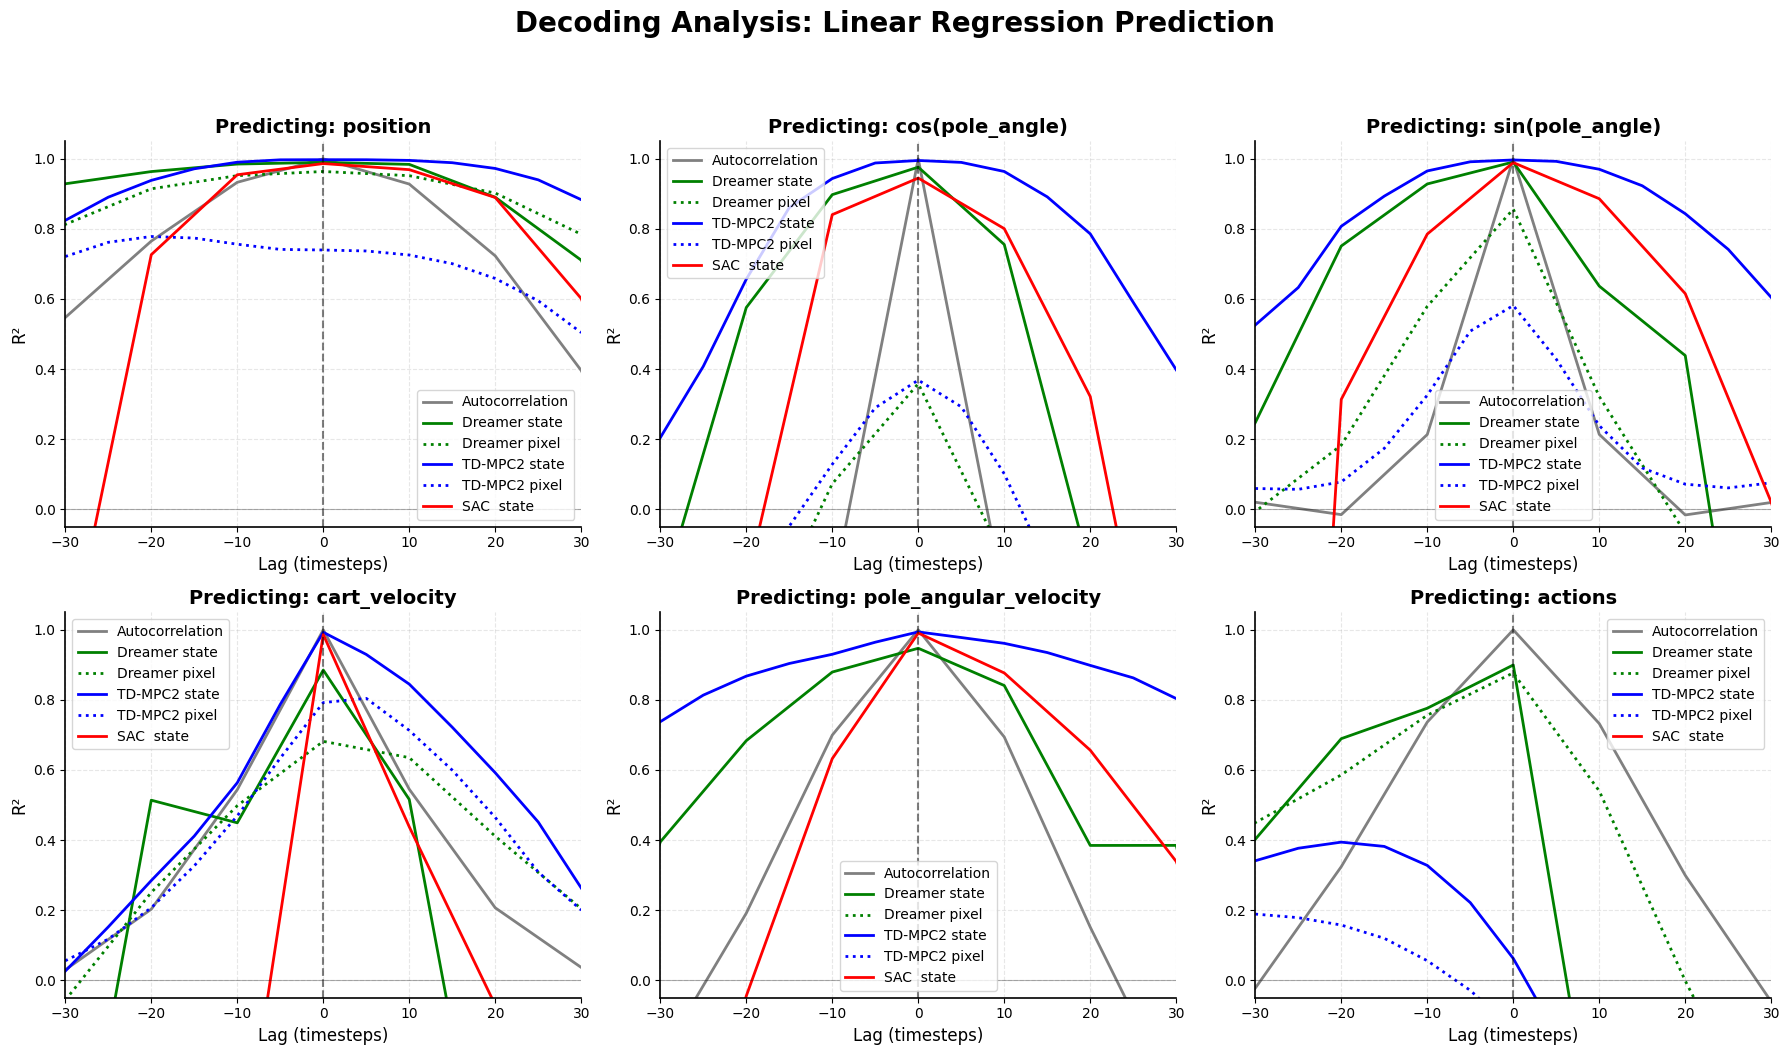

In [9]:
# Group plot keys by y variable
y_variables = [
    'position',
    'cos(pole_angle)',
    'sin(pole_angle)',
    'cart_velocity',
    'pole_angular_velocity',
    # 'rewards',
    'actions',
]

# Set 3 plots per row
n_cols = 3
n_vars = len(y_variables)
n_rows = (n_vars + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
axes = axes.flatten()  # Flatten to make indexing easier


# Define color and line styles for model and input type
def get_curve_style(x_var):
    # Returns color, linestyle, model_label, input_label
    if x_var.startswith('z_tdmpc2_'):
        color = 'blue'
        model_label = 'TD-MPC2'
    elif x_var.startswith('z_dreamer'):
        color = 'green'
        model_label = 'Dreamer'
    elif x_var.startswith('z_sac'):
        color = 'red'
        model_label = 'SAC'
    else:
        color = 'gray'
        model_label = 'Autocorrelation'

    if x_var.endswith('_pixel'):
        linestyle = ':'
        input_label = 'pixel'
    elif x_var.endswith('_state'):
        linestyle = '-'
        input_label = 'state'
    elif x_var.startswith('z_sac'):
        linestyle = '-'
        input_label = ' state'
    else:
        linestyle = '-'
        input_label = 'obs'

    return color, linestyle, model_label, input_label


for idx, y_var in enumerate(y_variables):
    # Get all x variables that predict this y variable
    plot_keys = [(x_var, y_var)
                 for x_var, y_var_check in decoding_relationships
                 if y_var_check == y_var]

    if not plot_keys:
        continue

    ax = axes[idx]

    # Plot each x variable as a separate line
    for x_var, _ in plot_keys:
        key = f'{x_var}-{y_var}'

        if key in results_decoding_all:
            results = results_decoding_all[key]
            r2_mean = results['r2_mean' if 'sac' in key else 'test_r2_mean']
            r2_ci = results['r2_ci' if 'sac' in key else 'test_r2_ci']
            lags = list(r2_mean.keys())
            means = list(r2_mean.values())
            ci_lower = [r2_ci[lag][0] for lag in lags]
            ci_upper = [r2_ci[lag][1] for lag in lags]

            color, linestyle, model_label, input_label = get_curve_style(x_var)
            pretty_label = f"{model_label} {input_label}" if model_label != 'Autocorrelation' else 'Autocorrelation'
            ax.plot(lags,
                    means,
                    linewidth=2,
                    label=pretty_label,
                    color=color,
                    linestyle=linestyle)
            # ax.fill_between(lags,
            #                 ci_lower,
            #                 ci_upper,
            #                 alpha=0.2,
            #                 color=color,
            #                 linestyle=linestyle)

    ax.set_xlabel('Lag (timesteps)', fontsize=12)
    ax.set_ylabel('R²', fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
    ax.set_ylim(-0.05, 1.05)
    #ax.set_xlim(-0.5, 30)
    ax.set_xlim(-30, 30)

    ax.tick_params(labelsize=10)
    ax.set_title(f'Predicting: {y_var}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

# Hide any unused subplots
for idx in range(len(y_variables), len(axes)):
    axes[idx].set_visible(False)

# Add overall title
fig.suptitle(f'Decoding Analysis: Linear Regression Prediction',
             fontsize=20,
             fontweight='bold',
             y=1.05)

plt.tight_layout()
sns.despine()
plt.show()

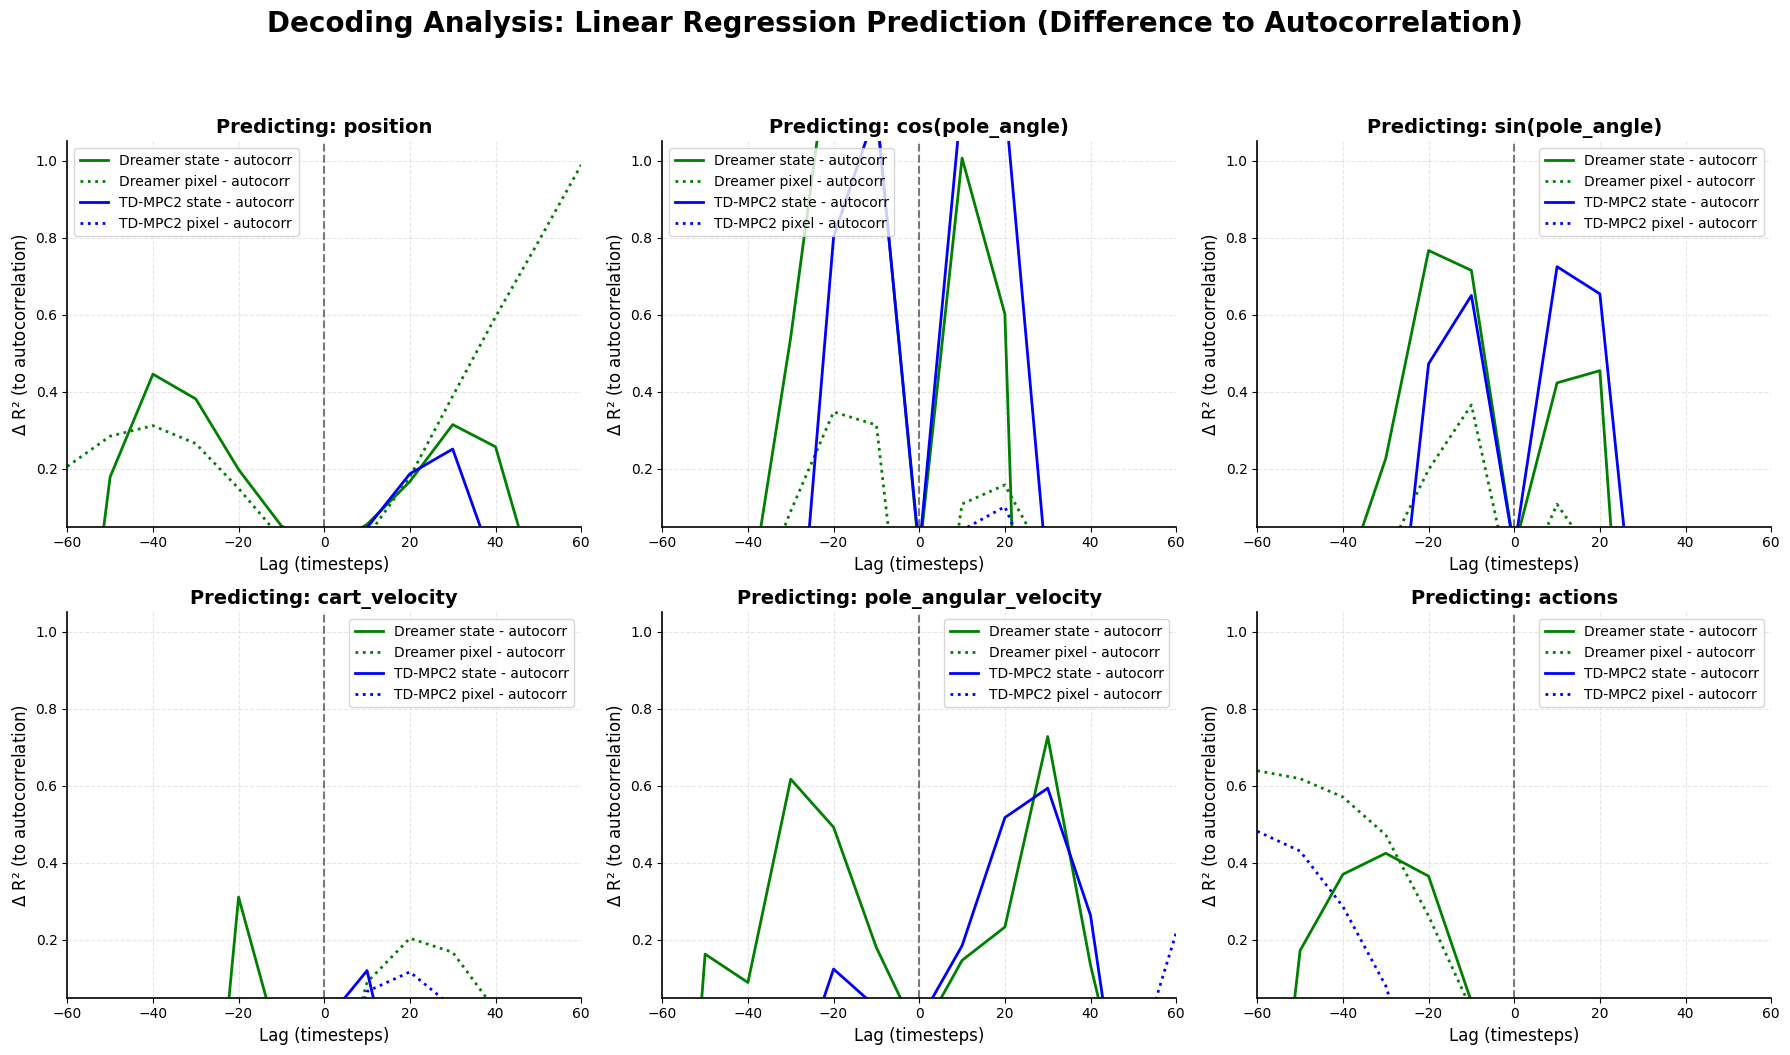

In [84]:
# Group plot keys by y variable
y_variables = [
    'position',
    'cos(pole_angle)',
    'sin(pole_angle)',
    'cart_velocity',
    'pole_angular_velocity',
    # 'rewards',
    'actions',
]

# Set 3 plots per row
n_cols = 3
n_vars = len(y_variables)
n_rows = (n_vars + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
axes = axes.flatten()  # Flatten to make indexing easier


def get_curve_style(x_var):
    # Returns color, linestyle, model_label, input_label
    if x_var.startswith('z_tdmpc2_'):
        color = 'blue'
        model_label = 'TD-MPC2'
    elif x_var.startswith('z_dreamer'):
        color = 'green'
        model_label = 'Dreamer'
    else:
        color = 'gray'
        model_label = 'Autocorrelation'

    if x_var.endswith('_pixel'):
        linestyle = ':'
        input_label = 'pixel'
    elif x_var.endswith('_state'):
        linestyle = '-'
        input_label = 'state'
    else:
        linestyle = '-'
        input_label = 'obs'

    return color, linestyle, model_label, input_label


for idx, y_var in enumerate(y_variables):
    # Get all x variables that predict this y variable
    plot_keys = [(x_var, y_var)
                 for x_var, y_var_check in decoding_relationships
                 if y_var_check == y_var]

    if not plot_keys:
        continue

    ax = axes[idx]

    # Compute autocorrelation curve (for this y_var)
    autocorr_key = f'{y_var}-{y_var}'
    if autocorr_key in results_decoding_all:
        autocorr_results = results_decoding_all[autocorr_key]
        autocorr_r2_mean = autocorr_results.get(
            'r2_mean', autocorr_results.get('test_r2_mean'))
        autocorr_lags = list(autocorr_r2_mean.keys())
        autocorr_means = list(autocorr_r2_mean.values())
    else:
        # skip if no autocorrelation available
        continue

    # Plot each x variable as a separate line (difference to autocorrelation)
    for x_var, _ in plot_keys:
        key = f'{x_var}-{y_var}'
        if key == autocorr_key:
            continue  # Don't plot autocorrelation-self diff line

        if key in results_decoding_all:
            results = results_decoding_all[key]
            r2_mean = results.get('r2_mean', results.get('test_r2_mean'))
            lags = list(r2_mean.keys())
            means = list(r2_mean.values())

            # Align with autocorr lags (assuming sorted and identical)
            # If not, match by lag value
            autocorr_mean_by_lag = {
                lag: val for lag, val in zip(autocorr_lags, autocorr_means)
            }
            # Only use lags present in both, to avoid KeyError
            use_lags = [lag for lag in lags if lag in autocorr_mean_by_lag]
            diff_means = [
                r2_mean[lag] - autocorr_mean_by_lag[lag] for lag in use_lags
            ]

            color, linestyle, model_label, input_label = get_curve_style(x_var)
            pretty_label = f"{model_label} {input_label} - autocorr"
            ax.plot(use_lags,
                    diff_means,
                    linewidth=2,
                    label=pretty_label,
                    color=color,
                    linestyle=linestyle)

    ax.set_xlabel('Lag (timesteps)', fontsize=12)
    ax.set_ylabel(r'$\Delta$ R² (to autocorrelation)', fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
    ax.set_ylim(0.05, 1.05)
    ax.set_xlim(-60, 60)
    ax.tick_params(labelsize=10)
    ax.set_title(f'Predicting: {y_var}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

# Hide any unused subplots
for idx in range(len(y_variables), len(axes)):
    axes[idx].set_visible(False)

# Add overall title
fig.suptitle(
    f'Decoding Analysis: Linear Regression Prediction (Difference to Autocorrelation)',
    fontsize=20,
    fontweight='bold',
    y=1.05)

plt.tight_layout()
sns.despine()
plt.show()